In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

In [2]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [3]:

load_dotenv(override=True)
import os


In [4]:
def get_groq_llm():
    return ChatOpenAI(
        model="openai/gpt-oss-20b",
        base_url="https://api.groq.com/openai/v1",
        api_key=os.getenv("GROQ_API_KEY"),
        temperature=0.7, max_tokens=2000
    )

llm = get_groq_llm()

In [5]:
def chat_node(state: ChatState):

    # take user query from state
    messages = state['messages']

    # send to llm
    response = llm.invoke(messages)

    # response store state
    return {'messages': [response]}

In [6]:
graph = StateGraph(ChatState)

# add nodes
graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile()

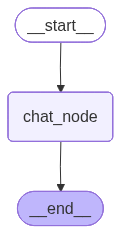

In [7]:
chatbot

In [8]:
initial_state = {
    'messages': [HumanMessage(content='What is the capital of india')]
}

chatbot.invoke(initial_state)


{'messages': [HumanMessage(content='What is the capital of india', additional_kwargs={}, response_metadata={}, id='3c66df4a-e5cf-486d-8a87-2c1530414780'),
  AIMessage(content='The capital of India is **New\u202fDelhi**.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 77, 'total_tokens': 118, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 21, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': None, 'queue_time': 0.050961844, 'prompt_time': 0.004374866, 'completion_time': 0.043401221, 'total_time': 0.047776087}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e99e93f2ac', 'id': 'chatcmpl-09f5d6dd-1fd3-44a1-96c1-e46f6e49b328', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e0d52-6288-7e42-bbb9-a5fe67a8e24e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input

In [9]:
initial_state = {
    'messages': [HumanMessage(content='HI there my name is sachin, How are you doing today?')]
}

chatbot.invoke(initial_state)

{'messages': [HumanMessage(content='HI there my name is sachin, How are you doing today?', additional_kwargs={}, response_metadata={}, id='cd193f38-c147-4604-98fd-73865e45a87c'),
  AIMessage(content='Hello Sachin! I’m doing great—thanks for asking. How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 72, 'prompt_tokens': 85, 'total_tokens': 157, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 43, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': None, 'queue_time': 0.048993758, 'prompt_time': 0.004705308, 'completion_time': 0.073554904, 'total_time': 0.078260212}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_5c8ca06ea1', 'id': 'chatcmpl-459de7c4-8ab3-41a3-9327-62d89d813d04', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e0d52-b668-7653-81d9-c3b6f2456e54-0', tool_

In [10]:
initial_state = {
    'messages': [HumanMessage(content='Hey do you remember my name?')]
}

chatbot.invoke(initial_state)['messages'][-1].content


'I don’t have that detail on hand—could you remind me?'

# ## Let's add memory


In [6]:
from langgraph.checkpoint.memory import InMemorySaver




In [7]:
graph = StateGraph(ChatState)

# add nodes
graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)




In [8]:
checkpointer = InMemorySaver()

chatbot = graph.compile(checkpointer=checkpointer)

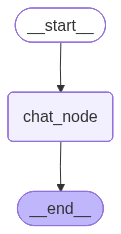

In [9]:
chatbot

In [10]:
config = {"configurable": {"thread_id": "1"}}


In [14]:
initial_state = {
    'messages': [HumanMessage(content='HI there my name is sachin')]
}

chatbot.invoke(initial_state,config=config)['messages'][-1].content

"Hello Sachin! 👋 How can I help you today? Whether you have a question, need assistance with something, or just want to chat, I'm here for you."

In [11]:
initial_state = {
    'messages': [HumanMessage(content='Do you remember my name?')]
}

chatbot.invoke(initial_state,config=config)['messages'][-1].content


'I don’t have any record of your name from this conversation. If you’d like to tell me, I’ll remember it for the rest of this chat!'